# **Exploratory data analysis for romanian dataset**

In [1]:
import pandas as pd
import json

data = []
skipped_lines = 0
with open("merged_dataset.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError:
            skipped_lines += 1
            continue

train_data = pd.DataFrame(data)
print(f"Skipped {skipped_lines} lines due to JSONDecodeError.")
train_data.head()

print(f"Total lines read successfully: {len(data)}")
print(train_data['AI_used'].value_counts(dropna=False))
print(train_data['AI_used'].unique())

Skipped 0 lines due to JSONDecodeError.
Total lines read successfully: 6120
AI_used
none                     3060
claude-sonnet-4-5        1020
gemini-3.5-flash-lite    1020
gpt-4-turbo              1020
Name: count, dtype: int64
['none' 'claude-sonnet-4-5' 'gemini-3.5-flash-lite' 'gpt-4-turbo']


In [2]:
print("Dimensiunea datasetului (instanțe, atribute):", train_data.shape)
print("\nTipurile de date:\n", train_data.dtypes)
print("\nPrimele 5 rânduri:\n", train_data.head())

Dimensiunea datasetului (instanțe, atribute): (6120, 7)

Tipurile de date:
 text                   object
label                  object
AI_used                object
chunk_no                int64
source                  int64
source_url             object
year_of_publication     int64
dtype: object

Primele 5 rânduri:
                                                 text  label AI_used  chunk_no  \
0  engineering (an existing interface is user req...  human    none         1   
1  duction, automated or not. formation, software...  human    none         2   
2  one interactive application to another. In thi...  human    none         3   
3  Of course, a tool may induce some method, but ...  human    none         4   
4  UIs and to introduce based on explicit transfo...  human    none         5   

   source                                         source_url  \
0       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
1       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   


In [3]:
print("\nStatistici descriptive (numerice):\n", train_data.describe())

print("\nStatistici descriptive (categorice):\n", train_data.describe(include=['object']))


Statistici descriptive (numerice):
           chunk_no       source  year_of_publication
count  6120.000000  6120.000000          6120.000000
mean      9.582353   106.679739          2011.013725
std       6.524853    57.458353             2.224191
min       1.000000     1.000000          2008.000000
25%       4.000000    57.000000          2009.000000
50%       8.000000   111.000000          2011.000000
75%      13.000000   158.000000          2013.000000
max      38.000000   196.000000          2015.000000

Statistici descriptive (categorice):
                                                      text  label AI_used  \
count                                                6120   6120    6120   
unique                                               6120      2       4   
top     În literatura de specialitate, evaluarea aplic...  human    none   
freq                                                    1   3060    3060   

                                               source_url  
count 

/tmp/ipykernel_7000/3546718321.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


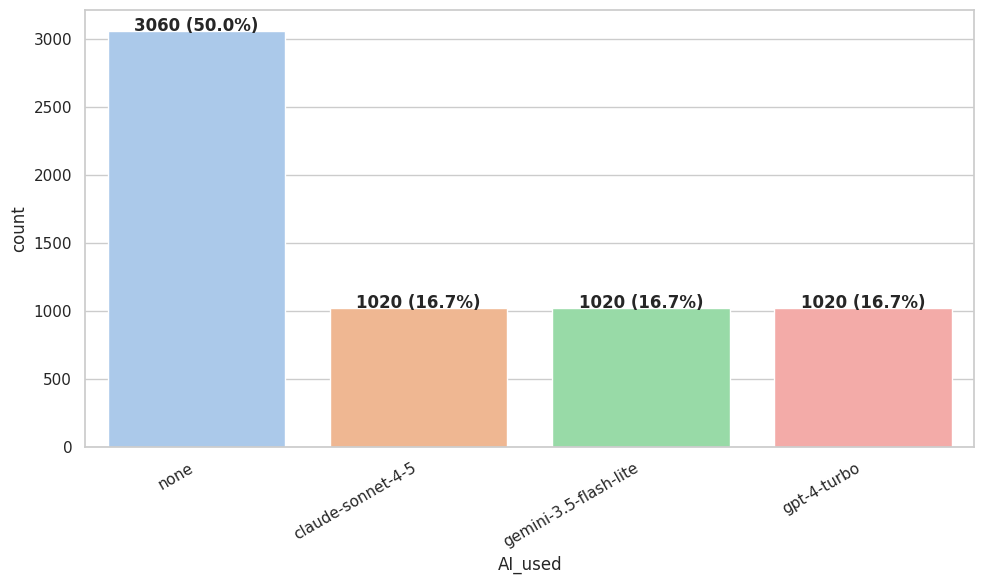

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=train_data,
    x='AI_used',
    order=train_data['AI_used'].value_counts().index,
    palette='pastel'
)


total = len(train_data)

for i, v in enumerate(train_data['AI_used'].value_counts()):
    percentage = (v / total) * 100
    plt.text(i, v + 1, f'{v} ({percentage:.1f}%)', ha='center', fontweight='bold')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


/tmp/ipykernel_7000/4071885888.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


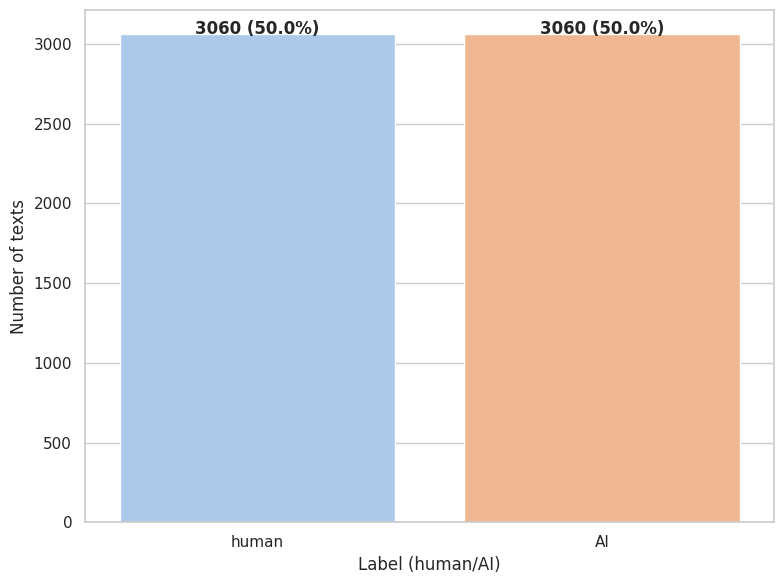

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.countplot(
    data=train_data,
    x='label',
    order=train_data['label'].value_counts().index,
    palette='pastel'
)

plt.xlabel('Label (human/AI)', fontsize=12)
plt.ylabel('Number of texts', fontsize=12)
plt.xticks(rotation=0)

label_counts = train_data['label'].value_counts()
total_labels = label_counts.sum()

for i, v in enumerate(label_counts):
    pct = f"{(v / total_labels) * 100:.1f}%"
    plt.text(i, v + 1, f"{v} ({pct})", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
